# RSA Speaker Fitting
**speaker_logit / speaker_choice → pRRSAc / pRRSAf 파라미터 추정**

| 모델 | 데이터 | 스케일 | RSA | Likelihood |
|------|--------|--------|-----|------------|
| A | speaker_logit  | log P_LLM(u\|s,r) | pRRSAc | Normal(log P_S1 + c, σ) |
| B | speaker_logit  | log P_LLM(u\|s,r) | pRRSAf | Normal(log P_S1 + c, σ) |
| C | speaker_choice | count(u\|s,r)     | pRRSAc | Multinomial(P_S1) |
| D | speaker_choice | count(u\|s,r)     | pRRSAf | Multinomial(P_S1) |

$$U_{\text{pRRSAc}}(u,s,r) = \phi_r\,U_{\text{epi}}(u,s) + (1-\phi_r)\cdot\alpha\cdot U_{\text{soc\_base}}(u)$$
$$U_{\text{pRRSAf}}(u,s,r) = \phi\,U_{\text{epi}}(u,s) + \alpha_r\cdot(1-\phi)\cdot U_{\text{soc\_base}}(u)$$

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from pathlib import Path

from variables import ADJECTIVES, RELATIONSHIP_VAR, STATE_VAR, ADJ_COLORS


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
# ── CONFIG ──────────────────────── (여기만 수정)
MODEL       = "qwen3_zero"   # "llama3" | "qwen3"
MCMC_DRAWS  = 2000
MCMC_TUNE   = 1000
MCMC_CHAINS = 4
# ────────────────────────────────────────────────

UTTERANCES = ADJECTIVES
STATES     = STATE_VAR
RELATIONS  = RELATIONSHIP_VAR
N_utt = len(UTTERANCES)
N_sta = len(STATES)
N_rel = len(RELATIONS)
print(f"model={MODEL}  utterances={UTTERANCES}  states={STATES}")

model=qwen3_zero  utterances=['großartig', 'gut', 'okay', 'schlecht', 'schrecklich']  states=[1, 2, 3, 4, 5]


---
## Step 1 — Semantics & L0
$$P_{L_0}(s \mid u) \propto [\![u]\!](s) \cdot P(s)$$

In [3]:
#                  s=1   s=2   s=3   s=4   s=5
SEM = np.array([
    [0.00000,0.03125,0.06250,0.15625,1.00000],  # großartig
    [0.03125,0.03125,0.65625,1.00000,0.90625],  # gut
    [0.06250,0.46875,0.93750,0.65625,0.46875],  # okay
    [0.90625,0.59375,0.06250,0.00000,0.00000],  # schlecht
    [0.84375,0.25000,0.00000,0.00000,0.00000]  # schrecklich
], dtype=float)

SEM = np.maximum(SEM, 0.01)   # 0 → 0.01 smoothing (log(0)=-∞ 방지)
prior_s = np.ones(N_sta) / N_sta
L0 = SEM * prior_s[np.newaxis, :]
L0 = L0 / L0.sum(axis=1, keepdims=True)

print("L0 — P_L0(s | u):")
pd.DataFrame(L0, index=UTTERANCES, columns=[f"s={s}" for s in STATES]).round(3)

L0 — P_L0(s | u):


,s=1,s=2,s=3,s=4,s=5
großartig,0.008,0.025,0.050,0.124,0.794
gut,0.012,0.012,0.250,0.381,0.345
okay,0.024,0.181,0.361,0.253,0.181
schlecht,0.573,0.375,0.039,0.006,0.006
schrecklich,0.751,0.222,0.009,0.009,0.009


## Step 2 — Utilities

**Epistemic utility** — how well the utterance conveys the intended state $s$:

$$U_{\text{epi}}(u, s) = \log P_{L_0}(s \mid u)$$

**Social utility base** — expected state value the listener infers from $u$, without $\alpha$:

$$U_{\text{soc\_base}}(u) = \sum_{s'} P_{L_0}(s' \mid u) \cdot s'$$

The full social utility $U_{\text{soc}}(u) = \alpha \cdot U_{\text{soc\_base}}(u)$ is formed by multiplying $\alpha$ inside the MCMC stage.

The two models differ in **which parameters vary by relationship**:

- **pRRSAc**: $\phi_r$ is relationship-specific; $\alpha$ is a single global scale.  
  $U(u,s,r) = \phi_r \cdot U_{\text{epi}}(u,s) + (1-\phi_r)\cdot\alpha\cdot U_{\text{soc\_base}}(u)$

- **pRRSAf**: $\alpha_r$ is relationship-specific; $\phi$ is a single global weight.  
  $U(u,s,r) = \phi \cdot U_{\text{epi}}(u,s) + \alpha_r\cdot(1-\phi)\cdot U_{\text{soc\_base}}(u)$

In [4]:
state_vals = np.array(STATES, dtype=float)

U_epi      = np.log(L0 + 1e-10)                        # (N_utt, N_sta)
U_soc_base = (L0 * state_vals[np.newaxis, :]).sum(1)   # (N_utt,)  α는 MCMC에서 곱함

print("U_epi:")
print(pd.DataFrame(U_epi, index=UTTERANCES, columns=[f"s={s}" for s in STATES]).round(3).to_string())
print("\nU_soc_base (α=1 for now, alpha will be multiplied afterwards):")
for u, v in zip(UTTERANCES, U_soc_base):
    print(f"  {u:12s}: {v:.3f}  {'█'*int(v*5)}")

U_epi:
               s=1    s=2    s=3    s=4    s=5
großartig   -4.836 -3.697 -3.004 -2.087 -0.231
gut         -4.431 -4.431 -1.386 -0.965 -1.064
okay        -3.726 -1.711 -1.018 -1.374 -1.711
schlecht    -0.557 -0.980 -3.232 -5.064 -5.064
schrecklich -0.287 -1.503 -4.722 -4.722 -4.722

U_soc_base (α=1 for now, alpha will be multiplied afterwards):
  großartig   : 4.671  ███████████████████████
  gut         : 4.036  ████████████████████
  okay        : 3.386  ████████████████
  schlecht    : 1.498  ███████
  schrecklich : 1.303  ██████


---
## Step 3 — Data Loading

In [5]:
def _parse_adj(text):
    text = str(text).lower()
    found = {a: m.start() for a in UTTERANCES
             if (m := re.search(rf"\b{a}\b", text))}
    return min(found, key=found.get) if found else None


def flat_speaker_logit(model):
    """
    각 CSV 행(situation × rep) × 5 adjectives = 독립 관측치
    logprob_: 5개 후보 내 renormalized log-prob = log P_LLM(u|s,r) 스케일
    반환: (rel_idx, sta_idx, utt_idx, obs)
    """
    p = Path(f"results/speaker_logit_{model}.csv")
    if not p.exists():
        print(f"[없음] {p}"); return None
    df = pd.read_csv(p)
    rows = []
    for _, row in df.iterrows():
        try:
            r_i = RELATIONS.index(row["relationship"])
            s_i = STATES.index(int(row["state"]))
        except ValueError:
            continue
        for u_i, adj in enumerate(UTTERANCES):
            col = f"logprob_{adj}"
            if col not in df.columns: continue
            rows.append({"rel_idx": r_i, "sta_idx": s_i,
                         "utt_idx": u_i, "obs": float(row[col])})
    df_f = pd.DataFrame(rows)
    n_cond = N_rel * N_sta * N_utt # 상황×발화 조합 수
    print(f"flat_speaker_logit_{model}: {len(df_f)} obs "
          f"({len(df_f)//n_cond} per condition)")
    # 관측치가 (rel, sta, utt) 조합마다 여러 개일 수 있지만, MCMC 피팅에서는 이걸 독립 관측으로 취급할 거라서 그냥 다 풀어서 1차원 배열로 반환
    return (df_f["rel_idx"].values.astype(int),
            df_f["sta_idx"].values.astype(int),
            df_f["utt_idx"].values.astype(int),
            df_f["obs"].values)


def load_speaker_counts(model):
    """counts_speaker[r, s, u] — situation+rep 합산"""
    p = Path(f"results/speaker_choice_{model}.csv")
    if not p.exists(): return print(f"[없음] {p}")
    df = pd.read_csv(p)
    df["utterance"] = df["response_text"].apply(_parse_adj)
    n_fail = df["utterance"].isna().sum()
    print(f"파싱 실패: {n_fail}/{len(df)} ({100*n_fail/len(df):.1f}%)")
    df = df.dropna(subset=["utterance"]) # 파싱 실패한 행 제거
    out = np.zeros((N_rel, N_sta, N_utt)) # (관계, 상황, 발화) 조합마다 count 저장할 배열
    for r_i, rel in enumerate(RELATIONS):
        for s_i, sta in enumerate(STATES): 
            mask = (df["relationship"] == rel) & (df["state"] == sta)
            # 각 발화(adj)마다 mask로 필터링된 행에서 utterance 열이 adj인 것들의 개수를 세서 out[r_i, s_i, u_i]에 저장
            for u_i, adj in enumerate(UTTERANCES):
            # 예: r_i=0(rel='Enge Freundin'), s_i=0(sta=1)인 행들 중에서 utterance가 'großartig'인 것들의 개수를 세서 out[0, 0, 0]에 저장
                out[r_i, s_i, u_i] = (df.loc[mask, "utterance"] == adj).sum()
    print(f"speaker_counts_{model}: {out.shape}, total={out.sum():.0f}")
    return out


def load_speaker_logit_avg(model):
    """[sanity/PPC 전용] situation 평균 logprobs_speaker[r, s, u]
    don't use it for MCMC fitting but use it for checking the visualization or PPC, because it averages logprobs across situations and reps, while flat_speaker_logit() treats each row as an independent observation without averaging."""
    p = Path(f"results/speaker_logit_{model}.csv")
    if not p.exists(): return print(f"[없음] {p}")
    df = pd.read_csv(p)
    out = np.zeros((N_rel, N_sta, N_utt))
    for r_i, rel in enumerate(RELATIONS):
        for s_i, sta in enumerate(STATES):
            mask = (df["relationship"] == rel) & (df["state"] == sta)
            for u_i, adj in enumerate(UTTERANCES):
                out[r_i, s_i, u_i] = df.loc[mask, f"logprob_{adj}"].mean()
    print(f"speaker_logit_avg_{model}: {out.shape}  ※ sanity/PPC 전용")
    return out

In [6]:
flat_sp          = flat_speaker_logit(MODEL)    # (rel,sta,utt,obs) | None
counts_speaker   = load_speaker_counts(MODEL)   # (N_rel,N_sta,N_utt) | None
logprobs_sp_avg  = load_speaker_logit_avg(MODEL) # sanity/PPC 전용

flat_speaker_logit_qwen3_zero: 500 obs (5 per condition)
파싱 실패: 0/1000 (0.0%)
speaker_counts_qwen3_zero: (4, 5, 5), total=1000
speaker_logit_avg_qwen3_zero: (4, 5, 5)  ※ sanity/PPC 전용


---
## Step 4 — PyMC Forward Models

```
build_rsa   → pRRSAc: U = φ_r·U_epi + (1-φ_r)·α·U_soc_base
build_rsa_f → pRRSAf: U = φ·U_epi + α_r·(1-φ)·U_soc_base
→ log_S1[r, u, s] = log P_S1(u | s, r)  (utterance 축 정규화)
```

In [7]:
def build_rsa(phi, alpha, lam):
    """pRRSAc — Speaker & Listener 공용
    U = φ_r·U_epi + (1-φ_r)·α·U_soc_base
    phi: (N_rel,)  alpha: scalar  lam: scalar
    """
    U_epi_t      = pt.as_tensor_variable(U_epi)
    U_soc_base_t = pt.as_tensor_variable(U_soc_base)
    phi_b = phi[:, None, None]
    U     = phi_b * U_epi_t[None, :, :] + (1 - phi_b) * alpha * U_soc_base_t[None, :, None]
    logits = lam * U
    log_S1 = logits - pt.logsumexp(logits, axis=1, keepdims=True)
    log_L1 = log_S1  - pt.logsumexp(log_S1,  axis=2, keepdims=True)
    return log_S1, log_L1


def build_rsa_f(alpha, phi, lam):
    """pRRSAf — Speaker & Listener 공용
    U = φ·U_epi + α_r·(1-φ)·U_soc_base
    alpha: (N_rel,)  phi: scalar  lam: scalar
    """
    U_epi_t      = pt.as_tensor_variable(U_epi)
    U_soc_base_t = pt.as_tensor_variable(U_soc_base)
    alpha_b = alpha[:, None, None]
    U       = phi * U_epi_t[None, :, :] + alpha_b * (1 - phi) * U_soc_base_t[None, :, None]
    logits  = lam * U
    log_S1  = logits - pt.logsumexp(logits, axis=1, keepdims=True)
    log_L1  = log_S1  - pt.logsumexp(log_S1,  axis=2, keepdims=True)
    return log_S1, log_L1


print("build_rsa / build_rsa_f 정의 완료")

build_rsa / build_rsa_f 정의 완료


---
## Step 5 — Sanity Check



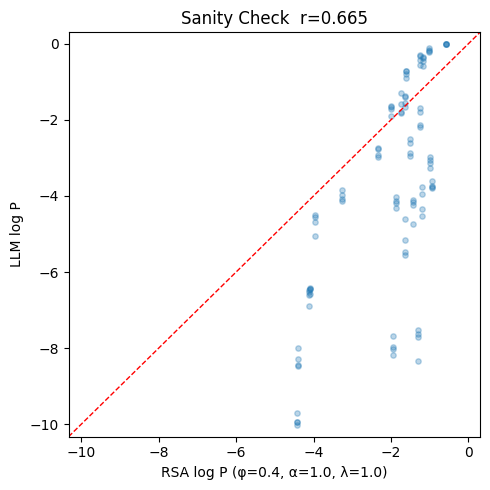

In [8]:
def rsa_speaker_np(s_idx, phi, alpha=1.0, lam=1.0):
    """numpy 버전 pRRSAc S1(u|s) — sanity/PPC 전용
    U = φ·U_epi + (1-φ)·α·U_soc_base
    """
    utility = phi * U_epi[:, s_idx] + (1 - phi) * alpha * U_soc_base
    logits  = lam * utility; logits -= logits.max()
    probs   = np.exp(logits)
    return probs / probs.sum()


if logprobs_sp_avg is not None:
    rsa_lp, llm_lp = [], []
    for r_i in range(N_rel):
        for s_i in range(N_sta):
            p = rsa_speaker_np(s_i, phi=0.4, alpha=1.0, lam=1.0)
            for u_i in range(N_utt):
                rsa_lp.append(np.log(p[u_i] + 1e-10))
                llm_lp.append(logprobs_sp_avg[r_i, s_i, u_i])
    rsa_lp, llm_lp = np.array(rsa_lp), np.array(llm_lp)
    r = np.corrcoef(rsa_lp, llm_lp)[0, 1]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(rsa_lp, llm_lp, alpha=0.3, s=15)
    lim = [min(rsa_lp.min(), llm_lp.min())-0.3, max(rsa_lp.max(), llm_lp.max())+0.3]
    ax.plot(lim, lim, 'r--', lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('RSA log P (φ=0.4, α=1.0, λ=1.0)'); ax.set_ylabel('LLM log P')
    ax.set_title(f'Sanity Check  r={r:.3f}')
    plt.tight_layout(); plt.savefig(f'results/sanity_speaker_{MODEL}.png', dpi=150); plt.show()

---
## Model A — Speaker Logit pRRSAc
$$\log P_{\text{LLM}}(u \mid s,r) \sim \mathcal{N}(\log P_{S1}(u \mid s,r) + c,\;\sigma)$$

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [phi, alpha, lam, c, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 15 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
phi[0]  0.635  0.145   0.369    0.880      0.004    0.003    1639.0    1866.0   
phi[1]  0.648  0.146   0.377    0.886      0.004    0.003    1618.0    1871.0   
phi[2]  0.659  0.140   0.401    0.891      0.003    0.002    1635.0    1831.0   
phi[3]  0.622  0.142   0.368    0.870      0.004    0.002    1643.0    1874.0   
alpha   1.470  0.918   0.161    3.315      0.023    0.017    1567.0    1774.0   
lam     1.654  0.560   1.075    2.509      0.015    0.011    1615.0    1755.0   
c      -1.028  0.113  -1.243   -0.828      0.002    0.001    4162.0    3660.0   
sigma   1.987  0.063   1.866    2.105      0.001    0.001    4188.0    3375.0   

        r_hat  
phi[0]    1.0  
phi[1]    1.0  
phi[2]    1.0  
phi[3]    1.0  
alpha     1.0  
lam       1.0  
c         1.0  
sigma     1.0  


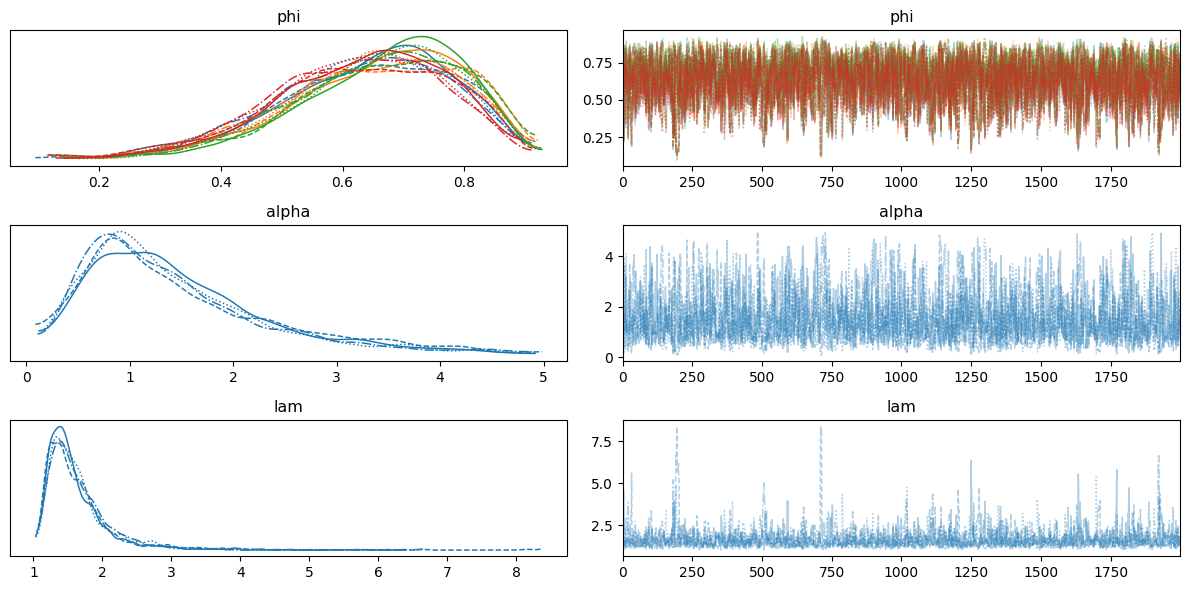

In [9]:
trace_A = None

if flat_sp is None:
    print('[skip] speaker_logit 없음')
else:
    rel_idx_sp, sta_idx_sp, utt_idx_sp, obs_sp = flat_sp

    with pm.Model() as model_A:
        phi   = pm.Uniform('phi',   lower=0, upper=1, shape=N_rel)
        alpha = pm.Uniform("alpha", lower=0, upper=5)               # global scalar

        lam   = pm.Uniform('lam',   lower=0, upper=20)
        c     = pm.Normal('c',      mu=0,    sigma=3)
        sigma = pm.HalfNormal('sigma', sigma=1)

        log_S1, _ = build_rsa(phi, alpha, lam)
        mu = log_S1[rel_idx_sp, utt_idx_sp, sta_idx_sp] + c 
        # log_S1[r, u, s]에서 (r, s, u) → (rel_idx_sp, utt_idx_sp, sta_idx_sp)로 인덱싱 
        pm.Normal('obs', mu=mu, sigma=sigma, observed=obs_sp) 
        # 관측값 obs_sp는 log P_LLM(u|s,r) 스케일

    with model_A:
        trace_A = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_A, var_names=['phi', 'alpha', 'lam', 'c', 'sigma']))
    az.plot_trace(trace_A, var_names=['phi', 'alpha', 'lam'])
    plt.tight_layout(); plt.show()

---
## Model B — Speaker Logit pRRSAf
$$\log P_{\text{LLM}}(u \mid s,r) \sim \mathcal{N}(\log P_{S1}(u \mid s,r) + c,\;\sigma)$$
$$U = \phi\cdot U_{\text{epi}} + \alpha_r\cdot(1-\phi)\cdot U_{\text{soc\_base}}$$

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi, lam, c, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 8 seconds.


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  3.336  0.927   1.757    4.993      0.026    0.018    1273.0   
alpha[1]  3.136  0.926   1.451    4.804      0.026    0.018    1276.0   
alpha[2]  3.316  0.926   1.759    4.973      0.026    0.018    1247.0   
alpha[3]  3.508  0.939   1.863    5.000      0.028    0.020    1153.0   
phi       0.830  0.051   0.740    0.895      0.002    0.001    1150.0   
lam       1.206  0.101   1.051    1.372      0.003    0.002    1553.0   
c        -1.026  0.113  -1.246   -0.819      0.002    0.001    4268.0   
sigma     1.985  0.063   1.864    2.102      0.001    0.001    5189.0   

          ess_tail  r_hat  
alpha[0]    1608.0    1.0  
alpha[1]    1594.0    1.0  
alpha[2]    1642.0    1.0  
alpha[3]    1692.0    1.0  
phi         1513.0    1.0  
lam         1333.0    1.0  
c           4936.0    1.0  
sigma       4949.0    1.0  


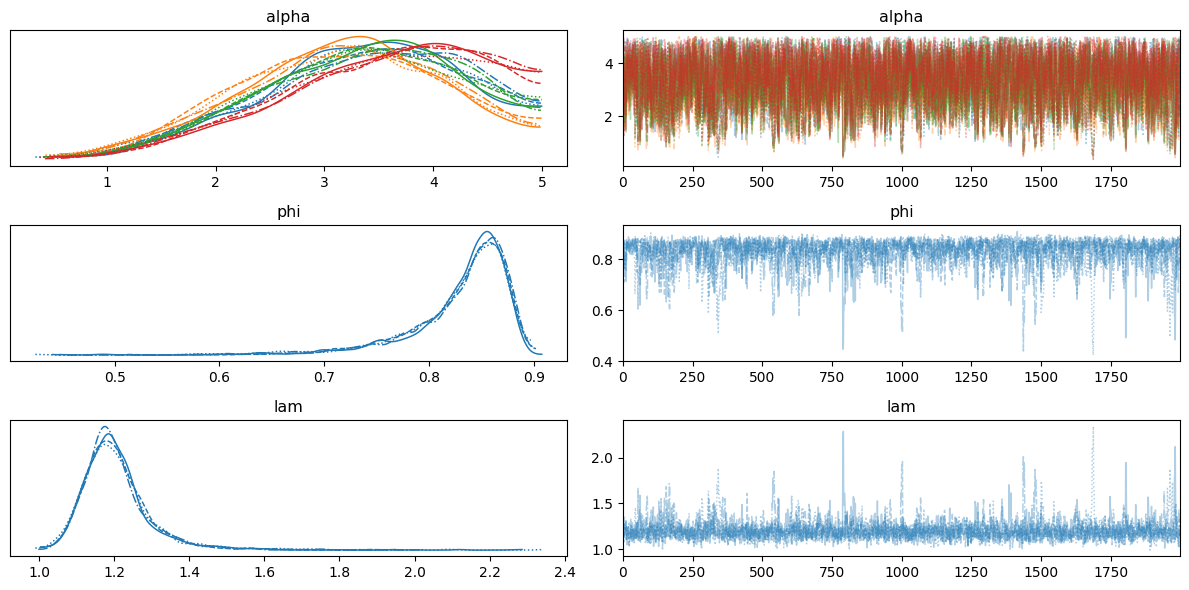

In [10]:
trace_B = None

if flat_sp is None:
    print('[skip] speaker_logit 없음')
else:
    rel_idx_sp, sta_idx_sp, utt_idx_sp, obs_sp = flat_sp

    with pm.Model() as model_B:
        alpha = pm.Uniform('alpha', lower=0, upper=5, shape=N_rel)
        phi   = pm.Uniform('phi',   lower=0, upper=1)
        lam   = pm.Uniform('lam',   lower=0, upper=20)
        c     = pm.Normal('c',      mu=0,    sigma=3)
        sigma = pm.HalfNormal('sigma', sigma=1)

        log_S1, _ = build_rsa_f(alpha, phi, lam)
        mu = log_S1[rel_idx_sp, utt_idx_sp, sta_idx_sp] + c
        pm.Normal('obs', mu=mu, sigma=sigma, observed=obs_sp)

    with model_B:
        trace_B = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_B, var_names=['alpha', 'phi', 'lam', 'c', 'sigma']))
    az.plot_trace(trace_B, var_names=['alpha', 'phi', 'lam'])
    plt.tight_layout(); plt.show()

---
## Model C — Speaker Choice pRRSAc (Multinomial)
$$\text{count}(u \mid s,r) \sim \text{Multinomial}(N,\;P_{S1}(u \mid s,r))$$

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [phi, lam, alpha]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
phi[0]  0.397  0.095   0.205    0.565      0.003    0.002    1081.0    1132.0   
phi[1]  0.350  0.083   0.182    0.499      0.003    0.002    1105.0    1139.0   
phi[2]  0.504  0.121   0.267    0.728      0.004    0.003    1040.0    1167.0   
phi[3]  0.807  0.157   0.505    1.000      0.005    0.004    1086.0    1186.0   
alpha   0.008  0.009   0.000    0.024      0.000    0.000    2426.0    2288.0   
lam     3.698  1.143   2.373    5.747      0.040    0.028    1012.0    1080.0   

        r_hat  
phi[0]    1.0  
phi[1]    1.0  
phi[2]    1.0  
phi[3]    1.0  
alpha     1.0  
lam       1.0  


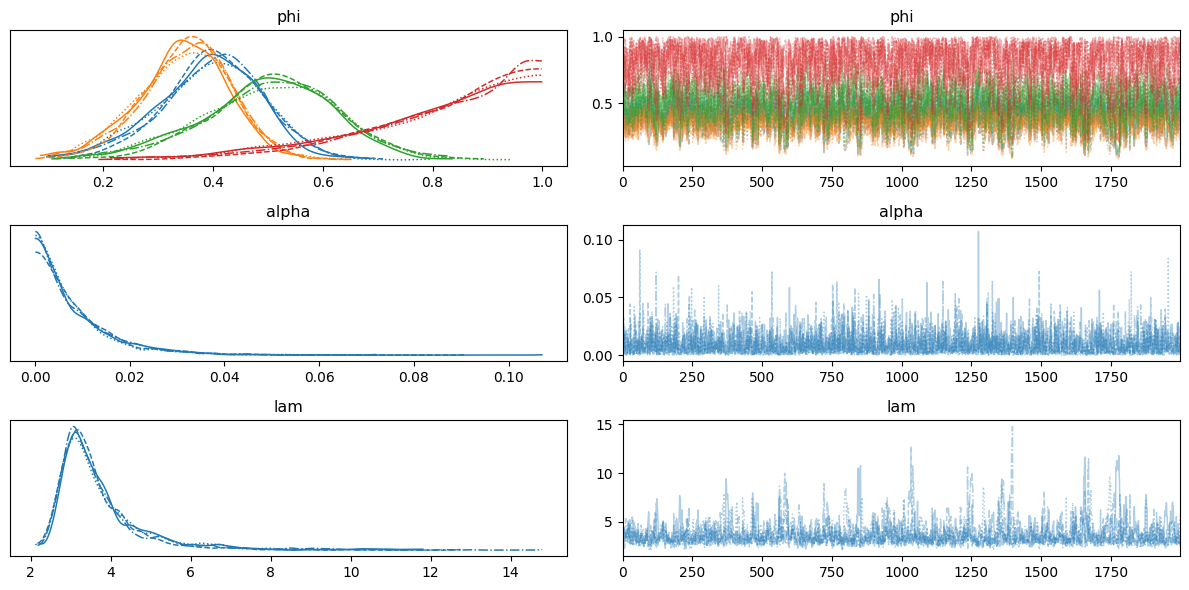

In [11]:
# Speaker _choice_prrsac

trace_C = None

if counts_speaker is None:
    print('[skip] speaker_choice 없음')
else:
    n_sp = counts_speaker.sum(axis=-1)   # (N_rel, N_sta)

    with pm.Model() as model_C:
        phi = pm.Uniform('phi', lower=0, upper=1, shape=N_rel)
        lam = pm.Uniform('lam', lower=0, upper=20)
        alpha = pm.Uniform("alpha", lower=0, upper=5)  # pRRSAc에서는 alpha는 그냥 1로 고정하거나, 아니면 phi와 함께 global scalar로 만들어도 됨

        log_S1, _ = build_rsa(phi, alpha, lam)
        P_S1 = pt.exp(log_S1).transpose(0, 2, 1)   # (N_rel, N_sta, N_utt)
        pm.Multinomial('obs', n=n_sp, p=P_S1, observed=counts_speaker)

    with model_C:
        trace_C = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_C, var_names=['phi', 'alpha', 'lam']))
    az.plot_trace(trace_C, var_names=['phi', 'alpha', 'lam'])
    plt.tight_layout(); plt.show()


---
## Model D — Speaker Choice pRRSAf (Multinomial)
$$\text{count}(u \mid s,r) \sim \text{Multinomial}(N,\;P_{S1}(u \mid s,r))$$
$$U = \phi\cdot U_{\text{epi}} + \alpha_r\cdot(1-\phi)\cdot U_{\text{soc\_base}}$$

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi, lam]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 5 seconds.


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  1.993  1.411   0.000    4.461      0.018    0.013    6020.0   
alpha[1]  1.979  1.408   0.000    4.460      0.016    0.012    6938.0   
alpha[2]  2.153  1.427   0.002    4.534      0.016    0.012    7781.0   
alpha[3]  2.675  1.408   0.382    4.983      0.016    0.012    7116.0   
phi       0.992  0.009   0.977    1.000      0.000    0.000    4165.0   
lam       1.613  0.081   1.462    1.765      0.001    0.001    7090.0   

          ess_tail  r_hat  
alpha[0]    4467.0    1.0  
alpha[1]    4826.0    1.0  
alpha[2]    4646.0    1.0  
alpha[3]    4866.0    1.0  
phi         3301.0    1.0  
lam         5345.0    1.0  


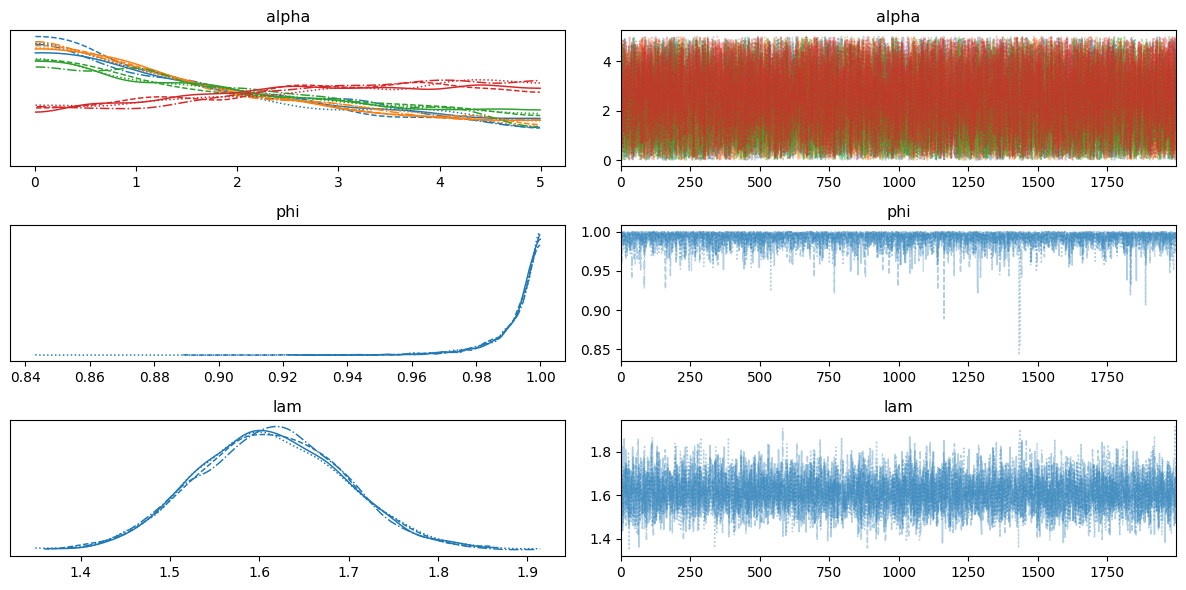

In [12]:
trace_D = None

if counts_speaker is None:
    print('[skip] speaker_choice 없음')
else:
    n_sp = counts_speaker.sum(axis=-1)

    with pm.Model() as model_D:
        alpha = pm.Uniform('alpha', lower=0, upper=5, shape=N_rel)
        phi   = pm.Uniform('phi',   lower=0, upper=1)
        lam   = pm.Uniform('lam',   lower=0, upper=20)

        log_S1, _ = build_rsa_f(alpha, phi, lam)
        P_S1 = pt.exp(log_S1).transpose(0, 2, 1)   # (N_rel, N_sta, N_utt)
        pm.Multinomial('obs', n=n_sp, p=P_S1, observed=counts_speaker)

    with model_D:
        trace_D = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_D, var_names=['alpha', 'phi', 'lam']))
    az.plot_trace(trace_D, var_names=['alpha', 'phi', 'lam'])
    plt.tight_layout(); plt.show()

---
## Step 6 — 인간 레퍼런스 (Lumer et al.)

In [13]:
#MAP
HUMAN_LAM   = 4.59
HUMAN_LAM_F = 2.25
HUMAN_PHI_C = {
    'Enge Freundin':      0.45,
    'Entfernte Kollegin': 0.31,
    'Lockere Chefin':     0.371,
    'Gefürchtete Chefin': 0.22,
}
HUMAN_PHI_F = 0.69
HUMAN_ALPHA_C = 0.61
HUMAN_ALPHA_F = {
    'Enge Freundin':      1.88,
    'Entfernte Kollegin': 2.90,
    'Lockere Chefin':     1.97,
    'Gefürchtete Chefin': 4.63,
}

# Mean values
HUMAN_TABLE_ME = {
    ('Enge Freundin',      'großartig'): 4.80,
    ('Enge Freundin',      'gut'): 3.31,
    ('Enge Freundin',      'okay'): 2.38,
    ('Enge Freundin',      'schlecht'): 1.12,
    ('Enge Freundin',      'schrecklich'): 1.18,
    ('Entfernte Kollegin', 'großartig'): 4.31, ('Entfernte Kollegin', 'gut'): 2.91,
    ('Entfernte Kollegin', 'okay'): 2.04,      ('Entfernte Kollegin', 'schlecht'): 1.26,
    ('Entfernte Kollegin', 'schrecklich'): 1.04,
    ('Lockere Chefin',     'großartig'): 4.46, ('Lockere Chefin',     'gut'): 3.27,
    ('Lockere Chefin',     'okay'): 2.30,      ('Lockere Chefin',     'schlecht'): 1.25,
    ('Lockere Chefin',     'schrecklich'): 1.07,
    ('Gefürchtete Chefin', 'großartig'): 3.69, ('Gefürchtete Chefin', 'gut'): 2.59,
    ('Gefürchtete Chefin', 'okay'): 1.67,      ('Gefürchtete Chefin', 'schlecht'): 1.19,
    ('Gefürchtete Chefin', 'schrecklich'): 1.11,
}
print('인간 레퍼런스 로드 완료')

인간 레퍼런스 로드 완료


---
## Step 7 — 결과 비교

In [188]:
# ── 수렴 진단 ─────────────────────────────────────────────────────────────────
TRACES = {
    'A: Speaker Logit  pRRSAc': (trace_A, 'phi'),
    'B: Speaker Logit  pRRSAf': (trace_B, 'alpha'),
    'C: Speaker Choice pRRSAc': (trace_C, 'phi'),
    'D: Speaker Choice pRRSAf': (trace_D, 'alpha'),
}
for name, (trace, pname) in TRACES.items():
    if trace is None:
        print(f'  {name:<32} [skip]'); continue
    rhat_vals = [float(az.rhat(trace)[v].values.max())
                 for v in [pname, 'lam'] if v in trace.posterior]
    max_r = max(rhat_vals) if rhat_vals else float('nan')
    status = '✓' if max_r < 1.01 else '△' if max_r < 1.05 else '✗'
    print(f'{status} {name:<32} max R-hat = {max_r:.4f}')

✓ A: Speaker Logit  pRRSAc         max R-hat = 1.0022
✓ B: Speaker Logit  pRRSAf         max R-hat = 1.0012
✓ C: Speaker Choice pRRSAc         max R-hat = 1.0055
✓ D: Speaker Choice pRRSAf         max R-hat = 1.0022


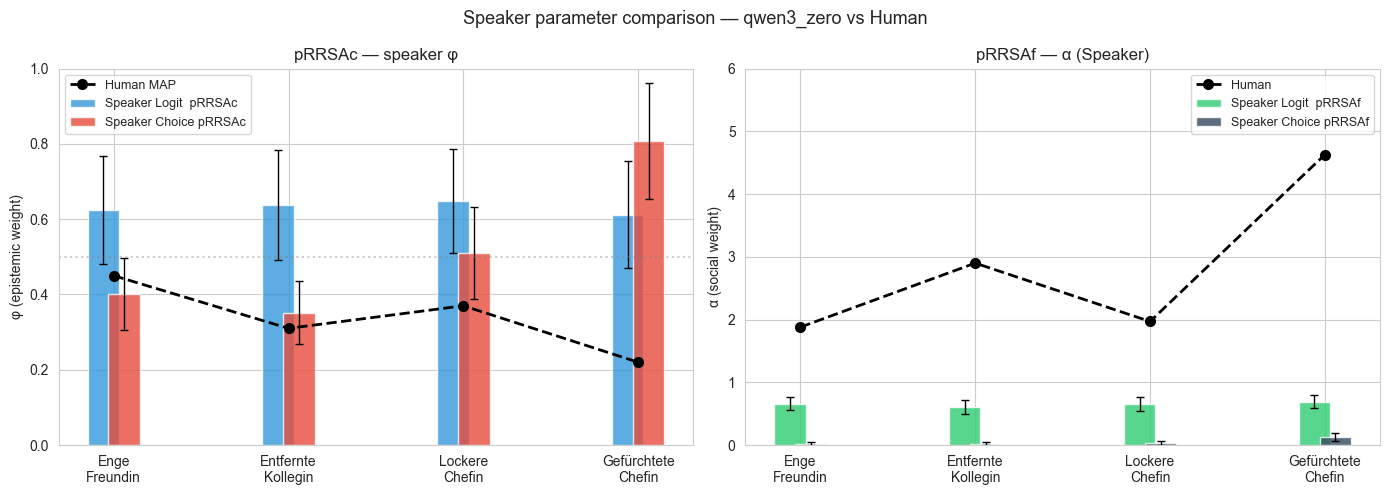

In [192]:

# ── φ / α 비교 플롯 ───────────────────────────────────────────────────────────
phi_traces   = {k: tr for k, (tr, param) in TRACES.items()
                if tr is not None and param == 'phi'   and 'phi'   in tr.posterior}
alpha_traces = {k: tr for k, (tr, param) in TRACES.items()
                if tr is not None and param == 'alpha' and 'alpha' in tr.posterior}

n_plots = (1 if phi_traces else 0) + (1 if alpha_traces else 0)
if n_plots == 0:
    print('[skip]')
else:
    fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))
    if n_plots == 1: axes = [axes]
    ax_idx = 0
    labels = [r.replace(' ', '\n') for r in RELATIONS]
    x = np.arange(N_rel); width = 0.18
    
    colors = {
        'A: Speaker Logit  pRRSAc': '#3498db',
        'B: Speaker Logit  pRRSAf': '#2ecc71',
        'C: Speaker Choice pRRSAc': '#e74c3c',
        'D: Speaker Choice pRRSAf': '#34495e',
    }

    if phi_traces:
        ax = axes[ax_idx]; ax_idx += 1
        offsets = np.linspace(-len(phi_traces)*width/2, len(phi_traces)*width/2,
                              len(phi_traces)+2)[1:-1]
        for i, (key, tr) in enumerate(phi_traces.items()):
            samp = tr.posterior['phi'].values
            m, s = samp.mean(axis=(0,1)), samp.std(axis=(0,1))
            label = key.split(': ', 1)[1]   # 'E: ' 접두어 제거
            ax.bar(x+offsets[i], m, width, label=label, color=colors[key], alpha=0.8)
            ax.errorbar(x+offsets[i], m, s, fmt='none', color='black', capsize=3, lw=1)
        ax.plot(x, [HUMAN_PHI[r] for r in RELATIONS], 'k--o', lw=2, ms=7, label='Human MAP')
        ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel('φ (epistemic weight)'); ax.set_ylim(0, 1)
        ax.axhline(0.5, color='gray', ls=':', alpha=0.4)
        ax.legend(fontsize=9); ax.set_title('pRRSAc — speaker φ')

    if alpha_traces:
        ax = axes[ax_idx]
        offsets = np.linspace(-len(alpha_traces)*width/2, len(alpha_traces)*width/2,
                              len(alpha_traces)+2)[1:-1]
        for i, (key, tr) in enumerate(alpha_traces.items()):
            samp = tr.posterior['alpha'].values
            m, s = samp.mean(axis=(0,1)), samp.std(axis=(0,1))
            label = key.split(': ', 1)[1]   # 'F: ' 접두어 제거
            ax.bar(x+offsets[i], m, width, label=label, color=colors[key], alpha=0.8)
            ax.errorbar(x+offsets[i], m, s, fmt='none', color='black', capsize=3, lw=1)
        ax.plot(x, [HUMAN_ALPHA[r] for r in RELATIONS], 'k--o', lw=2, ms=7, label='Human')
        ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel('α (social weight)'); ax.set_ylim(0, 6)
        ax.legend(fontsize=9); ax.set_title('pRRSAf — α (Speaker)')

    fig.suptitle(f'Speaker parameter comparison — {MODEL} vs Human', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'results/speaker_params_{MODEL}.png', dpi=150, bbox_inches='tight')
    plt.show()

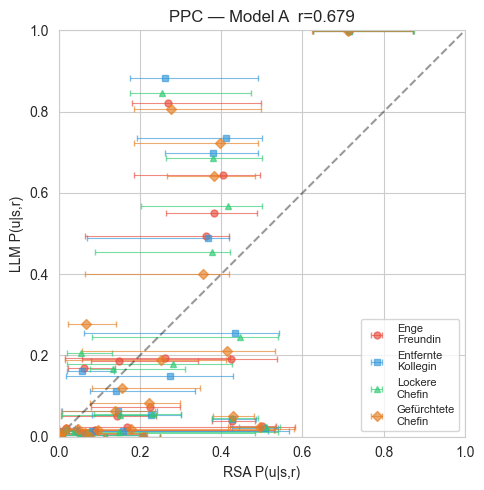

In [190]:
# ── Posterior Predictive Check (Model A) ──────────────────────────────────────
"""
RSA 모델이 예측한 확률" vs "LLM이 실제로 출력한 확률" 을 점으로 찍는 산점도.
점들이 대각선(k--)에 가까울수록 RSA 모델이 LLM을 잘 설명함
r값 (상관계수): 1에 가까울수록 예측이 정확
x축 오차막대: MCMC posterior의 불확실성 (3~97 percentile) — 넓을수록 파라미터 추정이 불안정
"""
if trace_A is None or logprobs_sp_avg is None:
    print('[skip]')
else:
    lam_s = trace_A.posterior['lam'].values.flatten()
    phi_s = trace_A.posterior['phi'].values.reshape(-1, N_rel)
    n_samp = len(lam_s)

    ppc_rows = []
    for r_i, rel in enumerate(RELATIONS):
        for s_i, sta in enumerate(STATES):
            probs_obs = np.exp(logprobs_sp_avg[r_i, s_i, :])
            for u_i, utt in enumerate(UTTERANCES):
                preds = np.array([rsa_speaker_np(s_i, phi=phi_s[j,r_i], lam=lam_s[j])[u_i]
                                  for j in range(n_samp)])
                ppc_rows.append({'relationship': rel, 'prob_obs': probs_obs[u_i],
                                 'pred_mean': preds.mean(),
                                 'pred_lo': np.percentile(preds,3),
                                 'pred_hi': np.percentile(preds,97)})

    df_ppc = pd.DataFrame(ppc_rows)
    colors = dict(zip(RELATIONS, ['#e74c3c','#3498db','#2ecc71','#e67e22']))
    markers = dict(zip(RELATIONS, ['o','s','^','D']))

    fig, ax = plt.subplots(figsize=(5,5))
    for rel in RELATIONS:
        d = df_ppc[df_ppc['relationship']==rel]
        ax.errorbar(d['pred_mean'], d['prob_obs'],
                    xerr=[d['pred_mean']-d['pred_lo'], d['pred_hi']-d['pred_mean']],
                    fmt=markers[rel], color=colors[rel],
                    label=rel.replace(' ','\n'), alpha=0.65, ms=5, capsize=2, lw=0.8)
    ax.plot([0,1],[0,1],'k--',alpha=0.4)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    r_ppc = np.corrcoef(df_ppc['pred_mean'], df_ppc['prob_obs'])[0,1]
    ax.set_title(f'PPC — Model A  r={r_ppc:.3f}')
    ax.set_xlabel('RSA P(u|s,r)'); ax.set_ylabel('LLM P(u|s,r)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'results/speaker_ppc_{MODEL}.png', dpi=150); plt.show()

In [191]:
# ── R², Top-1, Top-2 Accuracy per relationship — pRRSAc (Model A) ───────────

import numpy as np
import pandas as pd

# ── MAP 파라미터로 RSA 예측 ──────────────────────────────────────────────────
phi_map = trace_A.posterior["phi"].mean(("chain", "draw")).values  # (N_rel,)
lam_map = float(trace_A.posterior["lam"].mean())
log_S1, _ = build_rsa(phi_map, lam_map)
S1_np = np.exp(log_S1.eval())   # (N_rel, N_utt, N_sta)

# LLM 관측값: (N_rel, N_sta, N_utt) → prob로 변환
# logprobs_sp_avg[r, s, u] → exp → renormalize per (r,s)
llm_prob = np.exp(logprobs_sp_avg)   # (N_rel, N_sta, N_utt)
llm_prob = llm_prob / llm_prob.sum(axis=2, keepdims=True)  # 행(utt)합=1

# ── 지표 계산 ────────────────────────────────────────────────────────────────
rows = []
for r_i, rel in enumerate(RELATIONS):
    rsa_flat, llm_flat = [], []
    top1_correct, top2_correct = 0, 0

    for s_i in range(N_sta):
        rsa_p = S1_np[r_i, :, s_i]   # (N_utt,) — RSA P(u|s,r)
        llm_p = llm_prob[r_i, s_i, :]  # (N_utt,) — LLM P(u|s,r)

        rsa_flat.extend(rsa_p)
        llm_flat.extend(llm_p)

        # Top-1: RSA 1위 == LLM 1위?
        rsa_top1 = np.argmax(rsa_p)
        llm_top1 = np.argmax(llm_p)
        top1_correct += int(rsa_top1 == llm_top1)

        # Top-2: LLM 1위가 RSA 상위 2개 안에 있나?
        rsa_top2 = set(np.argsort(rsa_p)[-2:])
        top2_correct += int(llm_top1 in rsa_top2)

    # R² (확률 스케일)
    rsa_flat = np.array(rsa_flat)
    llm_flat = np.array(llm_flat)
    ss_res = ((llm_flat - rsa_flat) ** 2).sum()
    ss_tot = ((llm_flat - llm_flat.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot

    rows.append({
        "Relationship":   rel,
        "LLM R²":             round(r2, 3),
        "Human R²":           HUMAN_R2[rel],
        "Top-1 Acc":      f"{top1_correct}/{N_sta}  ({100*top1_correct/N_sta:.0f}%)",
        "Top-2 Acc":      f"{top2_correct}/{N_sta}  ({100*top2_correct/N_sta:.0f}%)",
    })

df_eval = pd.DataFrame(rows)
print("Model A (pRRSAc) Evaluation:")
print(df_eval.to_string(index=False))

TypeError: build_rsa() missing 1 required positional argument: 'lam'